### Importing Important libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime as dt
import plotly.express as px
import plotly.graph_objects as go
import plotly.colors
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

#### loading and reading data

In [7]:
data=pd.read_csv('online_retail.csv')
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [8]:
#inspection
print(data.shape)
print(data.info())
print(data.describe())
print(data.dtypes)

(541909, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB
None
            Quantity      UnitPrice     CustomerID
count  541909.000000  541909.000000  406829.000000
mean        9.552250       4.611114   15287.690570
std       218.081158      96.759853    1713.600303
min    -80995.000000  -11062.060000   12346.000000
25%         1.000000       1.250000   13953.000000
50%         3.000000       2.080000   15152.000000
75%        10.000000   

### Checking null values

In [9]:
data.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [10]:
data.dropna(subset=['CustomerID'],inplace=True)
data.shape

(406829, 8)

### Calculating Sales

In [11]:
data['Sales']=data['Quantity']*data['UnitPrice']
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


### Aaverage purchase value and purchase frequency

In [12]:
avg_purchase = data.groupby('CustomerID')['Sales'].mean()
purchase_frequency = data.groupby('CustomerID')['InvoiceNo'].nunique()
customer_lifetime_value = data.groupby('CustomerID')['Sales'].sum()
print('Average Purchase Value:\n',avg_purchase)
print("\n\nPurchase_Frequency:\n",purchase_frequency)
print("\n\nCustomer Lifetime Value\n",customer_lifetime_value)

Average Purchase Value:
 CustomerID
12346.0     0.000000
12347.0    23.681319
12348.0    57.975484
12349.0    24.076027
12350.0    19.670588
             ...    
18280.0    18.060000
18281.0    11.545714
18282.0    13.584615
18283.0     2.771005
18287.0    26.246857
Name: Sales, Length: 4372, dtype: float64


Purchase_Frequency:
 CustomerID
12346.0     2
12347.0     7
12348.0     4
12349.0     1
12350.0     1
           ..
18280.0     1
18281.0     1
18282.0     3
18283.0    16
18287.0     3
Name: InvoiceNo, Length: 4372, dtype: int64


Customer Lifetime Value
 CustomerID
12346.0       0.00
12347.0    4310.00
12348.0    1797.24
12349.0    1757.55
12350.0     334.40
            ...   
18280.0     180.60
18281.0      80.82
18282.0     176.60
18283.0    2094.88
18287.0    1837.28
Name: Sales, Length: 4372, dtype: float64


###  Customer lifetime value


In [13]:
print("Customer Lifetime Value\n",customer_lifetime_value)

Customer Lifetime Value
 CustomerID
12346.0       0.00
12347.0    4310.00
12348.0    1797.24
12349.0    1757.55
12350.0     334.40
            ...   
18280.0     180.60
18281.0      80.82
18282.0     176.60
18283.0    2094.88
18287.0    1837.28
Name: Sales, Length: 4372, dtype: float64


In [14]:
data['InvoiceDate']=pd.to_datetime(data['InvoiceDate'])

In [16]:
from datetime import timedelta
ref_date = data['InvoiceDate'].max() + timedelta(days=1)

### Feature selection
* Recency
* Frequency
* Monetary

In [17]:
rfm=data.groupby('CustomerID').agg(
    {
        'InvoiceDate':lambda x:(ref_date - x.max()).days,
        'CustomerID':'count',
        'Sales':'sum'
    }
)
rfm.rename(columns={'InvoiceDate':'Recency','CustomerID':'Frequency','Sales':'Monetary'},inplace=True)
rfm

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,2,0.00
12347.0,2,182,4310.00
12348.0,75,31,1797.24
12349.0,19,73,1757.55
12350.0,310,17,334.40
...,...,...,...
18280.0,278,10,180.60
18281.0,181,7,80.82
18282.0,8,13,176.60


In [18]:
rfm.describe()

,Recency,Frequency,Monetary
count,4372.000000,4372.000000,4372.000000
mean,92.047118,93.053294,1898.459701
std,100.765435,232.471608,8219.345141
min,1.000000,1.000000,-4287.630000
25%,17.000000,17.000000,293.362500
50%,50.000000,42.000000,648.075000
75%,143.000000,102.000000,1611.725000
max,374.000000,7983.000000,279489.020000


### Standization using StandaedScaler()

In [19]:
# Standardization
scaler = StandardScaler()
rfm_scaled=scaler.fit_transform(rfm[['Recency','Frequency','Monetary']])

rfm_scaled_data=pd.DataFrame(rfm_scaled,columns=['Recency','Frequency','Monetary'],index=rfm.index)

In [20]:
rfm_scaled_data

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,2.322023,-0.391720,-0.231001
12347.0,-0.893733,0.382657,0.293432
12348.0,-0.169196,-0.266959,-0.012316
12349.0,-0.725005,-0.086271,-0.017146
12350.0,2.163220,-0.327188,-0.190312
...,...,...,...
18280.0,1.845615,-0.357303,-0.209026
18281.0,0.882873,-0.370209,-0.221167
18282.0,-0.834182,-0.344397,-0.209513


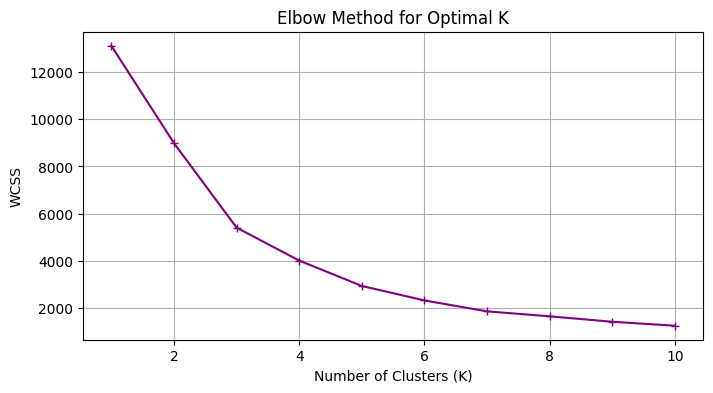

In [29]:
# Elbow Method
wcss=[]
for i in range(1,11):
    kmeans=KMeans(n_clusters=i,random_state=42,n_init=10)
    kmeans.fit(rfm_scaled_data)
    wcss.append(kmeans.inertia_)
#elbow curve
plt.figure(figsize=(8,4))
plt.plot(range(1,11),wcss ,marker='+',color='purple')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.grid()
plt.show()

In [24]:
# The Curve is more bend at K=3
#Applying K means
optimal_k=3
kmeans=KMeans(n_clusters=optimal_k,random_state=42,n_init=10)
rfm['Cluster']=kmeans.fit_predict(rfm_scaled_data)

### Comparing 2 main Features

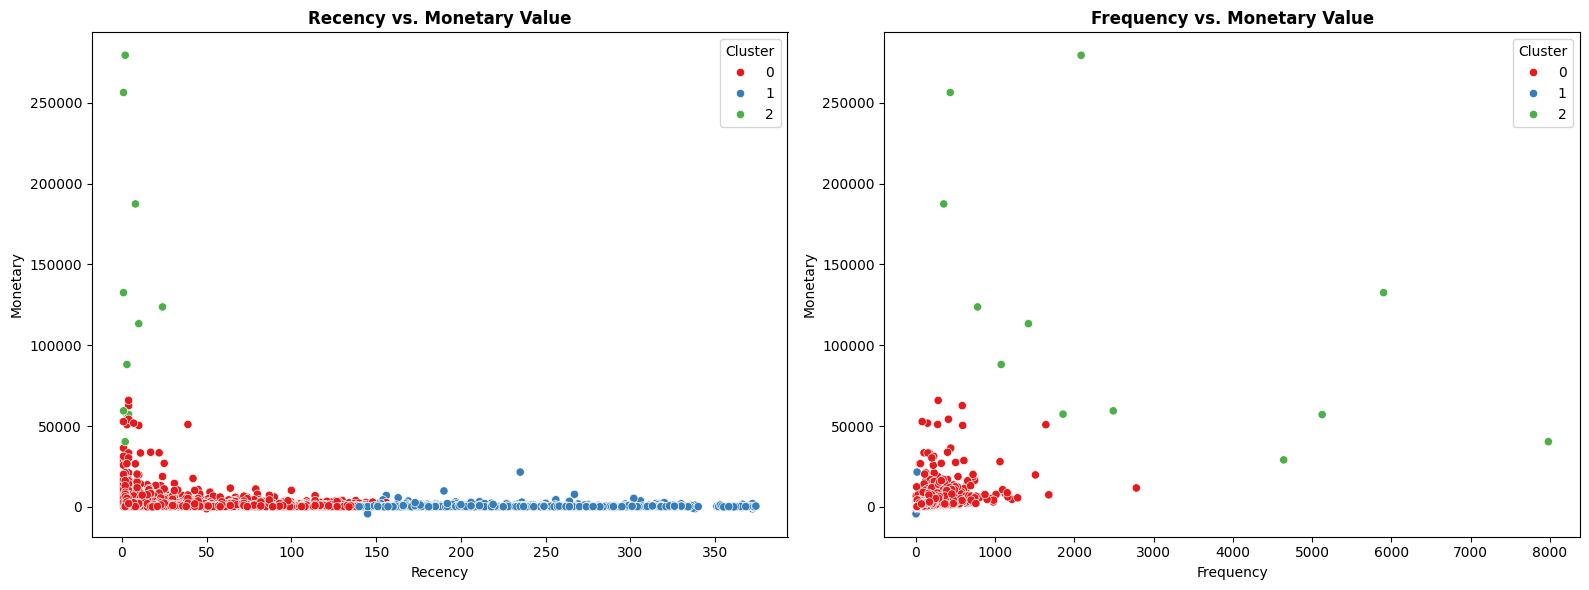

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Recency vs. Monetary
sns.scatterplot(
    data=rfm, x='Recency', y='Monetary', hue='Cluster', palette='Set1', ax=axes[0]
)
axes[0].set_title('Recency vs. Monetary Value', fontweight='bold')

# Frequency vs. Monetary
sns.scatterplot(
    data=rfm, x='Frequency', y='Monetary', hue='Cluster', palette='Set1', ax=axes[1]
)
axes[1].set_title('Frequency vs. Monetary Value', fontweight='bold')

plt.tight_layout()
plt.show()

In [32]:
# Profile each cluster
cluster_profile = rfm.groupby('Cluster').mean()
print(cluster_profile)


            Recency    Frequency       Monetary
Cluster                                        
0         40.254289   104.874694    1950.597005
1        247.244526    27.710766     464.197911
2          5.000000  2845.583333  118713.023333


C:\Users\ALI PC\AppData\Local\Temp\ipykernel_25116\2880931865.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=rfm, x='Cluster', palette='Set1')


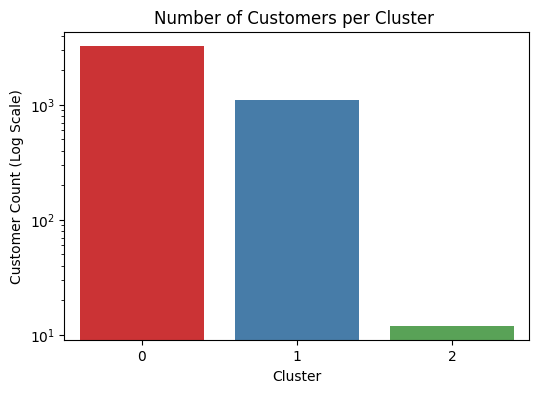

In [33]:
plt.figure(figsize=(6,4))

sns.countplot(data=rfm, x='Cluster', palette='Set1')

plt.yscale('log')

plt.title("Number of Customers per Cluster ")
plt.xlabel("Cluster")
plt.ylabel("Customer Count (Log Scale)")

plt.show()

## Customer Segment Profiles

### Cluster 0 – Loyal Customers
- Moderate recency (recent purchases)
- High purchase frequency
- High spending

**Customer Type:** Loyal Customers

**Recommendation:**
- Loyalty reward programs
- Personalized product recommendations
- Exclusive discounts

---

### Cluster 1 – Inactive / At-Risk Customers
- Highest recency (least recent purchases)
- Low purchase frequency
- Low spending

**Customer Type:** Inactive Customers

**Recommendation:**
- Re-engagement email campaigns
- Discount coupons
- Limited-time promotional offers

---

### Cluster 2 – VIP / High-Value Customers
- Lowest recency (most recent purchases)
- Extremely high purchase frequency
- Highest monetary value

**Customer Type:** VIP Customers

**Recommendation:**
- VIP membership
- Early access to new products
- Premium customer support
- Exclusive rewards